# Lista 5

## scikit

(5pkt + 2pkt)

Na liÅ›cie znajdujÄ… siÄ™ 4 zadania. Po rozwiÄ…zaniu zadania pokaÅ¼ kod prowadzÄ…cemu i odpowiedz na **pytanie kontrolne** â€” tylko wtedy przyznajemy punkty. Dodatkowo przeÅ›lij zadanie na platformie skos.

Zadania dodatkowe oznaczone sÄ… â­ï¸. Za wykonanie kaÅ¼dego z nich otrzymasz 1pkt. 
**Uwaga** jedno z zadaÅ„ moÅ¼liwe jest do wykonania tylko podczas pracowni!

## Intro: Regresja liniowa

Wygeneruj sztuczny zbiÃ³r danych regresyjnych za pomocÄ… funkcji `make_regression(n_samples=200, n_features=1, noise=10)`. NastÄ™pnie podziel dane na zbiÃ³r treningowy i testowy (`train_test_split`) i wykonaj regresjÄ™. Policz bÅ‚Ä™dy modelu na zbiorze testowym.

KtÃ³ry z modeli regresji daje najlepsze wyniki? PorÃ³wnaj trzy modele z wykÅ‚adu.

LinearRegression()
MAE  (Mean Absolute Error): 9.05
MSE  (Mean Squared Error): 122.8


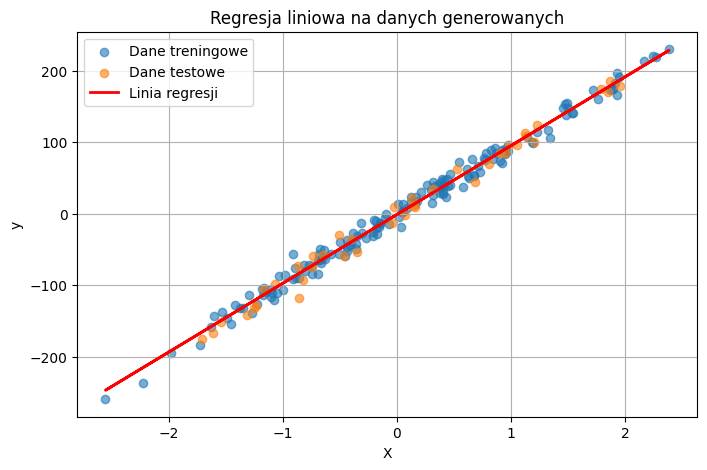

Lasso()
MAE  (Mean Absolute Error): 9.21
MSE  (Mean Squared Error): 126.79


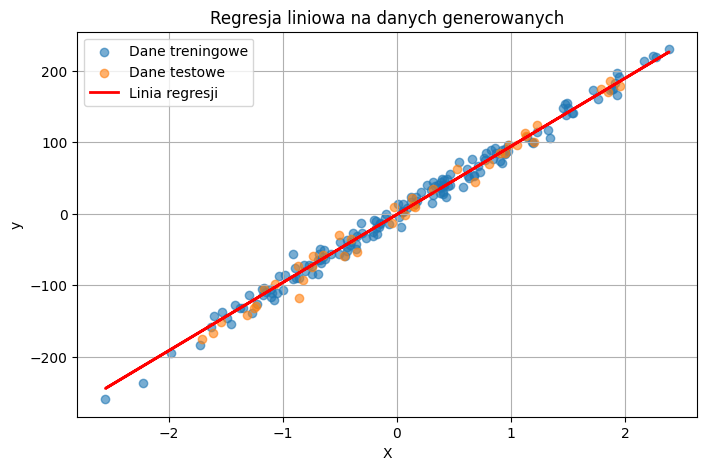

Ridge()
MAE  (Mean Absolute Error): 9.15
MSE  (Mean Squared Error): 124.93


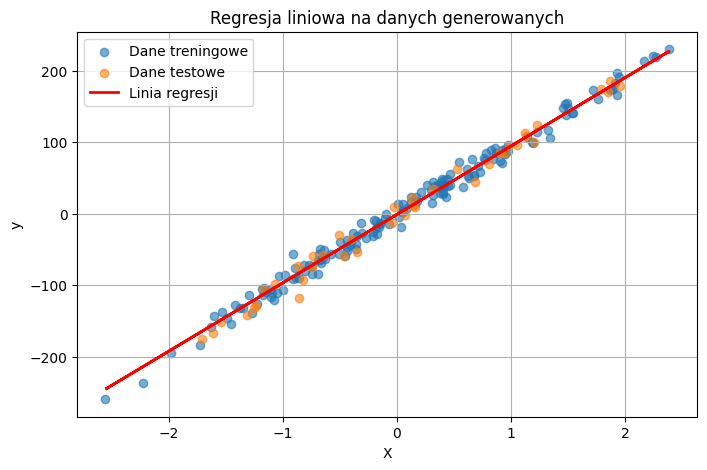

In [38]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# Generowanie danych
X, y = make_regression(n_samples=200, n_features=1, noise=10, random_state=0)

# 2. PodziaÅ‚ danych
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

for model in [LinearRegression(), Lasso(), Ridge()]:
    # 3. Model regresji liniowej
    model.fit(X_train, y_train)
    print(str(model))

    # 4. Predykcje
    y_pred = model.predict(X_test)

    # 5. BÅ‚Ä™dy regresji
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    print("MAE  (Mean Absolute Error):", round(mae, 2))
    print("MSE  (Mean Squared Error):", round(mse, 2))

    # 6. Wykres: dane + linia regresji
    plt.figure(figsize=(8,5))
    plt.scatter(X_train, y_train, alpha=0.6, label="Dane treningowe")
    plt.scatter(X_test, y_test, alpha=0.6, label="Dane testowe")
    plt.plot(X, model.predict(X), color='red', linewidth=2, label="Linia regresji")

    plt.xlabel("X")
    plt.ylabel("y")
    plt.title("Regresja liniowa na danych generowanych")
    plt.legend()
    plt.grid(True)
    plt.show()

## Rozpoznawanie rÄ™cznie pisanych cyfr

Celem zadania jest klasyfikacja obrazÃ³w cyfr 0â€“9 i eksperymentowanie z parametrami klasyfikatora **SVC (Support Vector Classifier)**. W tym zadaniu bÄ™dziesz pracowaÄ‡ na zbiorze **Digits** z pakietu `sklearn`, ktÃ³ry zawiera obrazy 8Ã—8 pikseli wraz z prawdziwymi etykietami cyfr.

Najpierw wyÅ›wietl kilka przykÅ‚adÃ³w obrazÃ³w, aby zobaczyÄ‡ strukturÄ™ danych. NastÄ™pnie spÅ‚aszcz obrazy 8Ã—8 do wektorÃ³w dÅ‚ugoÅ›ci 64 (`numpy.reshape` na `digits.images`) i podziel dane na zbiÃ³r treningowy i testowy.

Twoim zadaniem jest przetestowanie SVC z kilkoma (trzy wystarczÄ…) rÃ³Å¼nymi parametrami (`C`, `gamma`) w celu znalezienia najlepszego zestawu dla tego zbioru. Dla kaÅ¼dej konfiguracji:

1. PrzeprowadÅº trenowanie na zbiorze treningowym,
2. Wykonaj predykcjÄ™ na zbiorze testowym,
3. Oblicz dokÅ‚adnoÅ›Ä‡ (`metrics.accuracy_score`) oraz wyÅ›wietl `metrics.classification_report`,
4. Narysuj **confusion matrix** (`metrics.ConfusionMatrixDisplay.from_predictions`).

Na koÅ„cu podsumuj:

* ktÃ³ry zestaw parametrÃ³w daÅ‚ najlepszÄ… dokÅ‚adnoÅ›Ä‡,
* ktÃ³re cyfry byÅ‚y najczÄ™Å›ciej mylone,
* czy zwiÄ™kszenie `C` lub zmiana `gamma` poprawiÅ‚o wyniki.


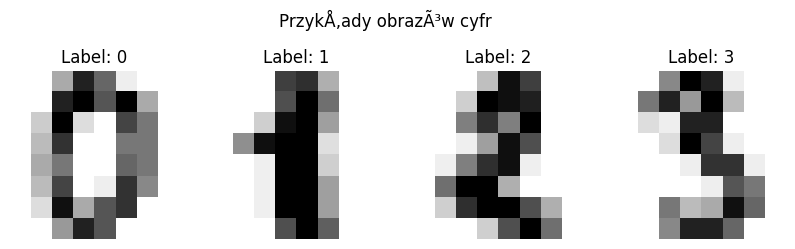

--- SVC (C=1.0, gamma=0.1) ---
Accuracy: 0.1012
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        88
           1       0.00      0.00      0.00        91
           2       0.00      0.00      0.00        86
           3       0.10      1.00      0.18        91
           4       0.00      0.00      0.00        92
           5       0.00      0.00      0.00        91
           6       0.00      0.00      0.00        91
           7       0.00      0.00      0.00        89
           8       0.00      0.00      0.00        88
           9       0.00      0.00      0.00        92

    accuracy                           0.10       899
   macro avg       0.01      0.10      0.02       899
weighted avg       0.01      0.10      0.02       899



/Users/karol/Desktop/CoursesUwr/7sem/AI_workshop/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/karol/Desktop/CoursesUwr/7sem/AI_workshop/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/karol/Desktop/CoursesUwr/7sem/AI_workshop/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

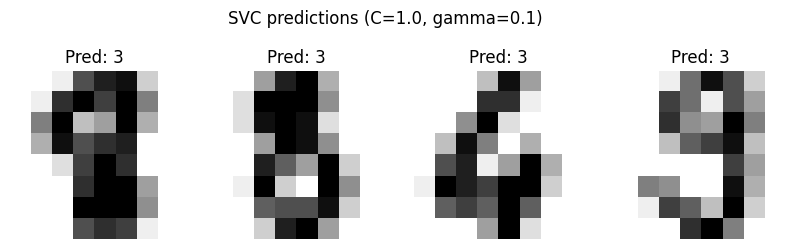

Confusion matrix:
[[ 0  0  0 88  0  0  0  0  0  0]
 [ 0  0  0 91  0  0  0  0  0  0]
 [ 0  0  0 86  0  0  0  0  0  0]
 [ 0  0  0 91  0  0  0  0  0  0]
 [ 0  0  0 92  0  0  0  0  0  0]
 [ 0  0  0 91  0  0  0  0  0  0]
 [ 0  0  0 91  0  0  0  0  0  0]
 [ 0  0  0 89  0  0  0  0  0  0]
 [ 0  0  0 88  0  0  0  0  0  0]
 [ 0  0  0 92  0  0  0  0  0  0]]
--- SVC (C=0.5, gamma=0.5) ---
Accuracy: 0.1012
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        88
           1       0.00      0.00      0.00        91
           2       0.00      0.00      0.00        86
           3       0.10      1.00      0.18        91
           4       0.00      0.00      0.00        92
           5       0.00      0.00      0.00        91
           6       0.00      0.00      0.00        91
           7       0.00      0.00      0.00        89
           8       0.00      0.00      0.00        88
           9       0.00      0.00      0.00        92

    acc

/Users/karol/Desktop/CoursesUwr/7sem/AI_workshop/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/karol/Desktop/CoursesUwr/7sem/AI_workshop/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/karol/Desktop/CoursesUwr/7sem/AI_workshop/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

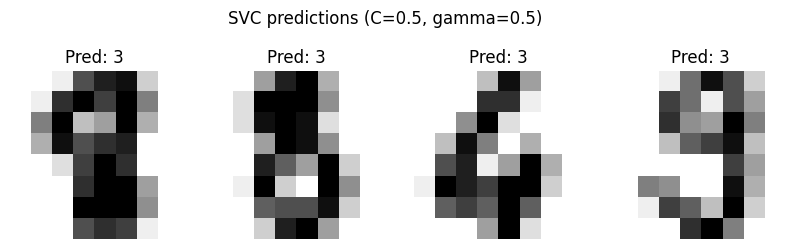

/Users/karol/Desktop/CoursesUwr/7sem/AI_workshop/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/karol/Desktop/CoursesUwr/7sem/AI_workshop/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/karol/Desktop/CoursesUwr/7sem/AI_workshop/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

Confusion matrix:
[[ 0  0  0 88  0  0  0  0  0  0]
 [ 0  0  0 91  0  0  0  0  0  0]
 [ 0  0  0 86  0  0  0  0  0  0]
 [ 0  0  0 91  0  0  0  0  0  0]
 [ 0  0  0 92  0  0  0  0  0  0]
 [ 0  0  0 91  0  0  0  0  0  0]
 [ 0  0  0 91  0  0  0  0  0  0]
 [ 0  0  0 89  0  0  0  0  0  0]
 [ 0  0  0 88  0  0  0  0  0  0]
 [ 0  0  0 92  0  0  0  0  0  0]]
--- SVC (C=0.1, gamma=1.0) ---
Accuracy: 0.1012
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        88
           1       0.00      0.00      0.00        91
           2       0.00      0.00      0.00        86
           3       0.10      1.00      0.18        91
           4       0.00      0.00      0.00        92
           5       0.00      0.00      0.00        91
           6       0.00      0.00      0.00        91
           7       0.00      0.00      0.00        89
           8       0.00      0.00      0.00        88
           9       0.00      0.00      0.00        92

    acc

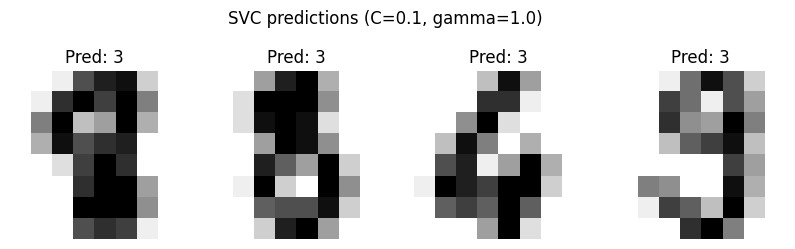

Confusion matrix:
[[ 0  0  0 88  0  0  0  0  0  0]
 [ 0  0  0 91  0  0  0  0  0  0]
 [ 0  0  0 86  0  0  0  0  0  0]
 [ 0  0  0 91  0  0  0  0  0  0]
 [ 0  0  0 92  0  0  0  0  0  0]
 [ 0  0  0 91  0  0  0  0  0  0]
 [ 0  0  0 91  0  0  0  0  0  0]
 [ 0  0  0 89  0  0  0  0  0  0]
 [ 0  0  0 88  0  0  0  0  0  0]
 [ 0  0  0 92  0  0  0  0  0  0]]


In [39]:
import matplotlib.pyplot as plt
from sklearn import datasets, metrics, svm
from sklearn.model_selection import train_test_split

# --- 1. Wczytaj dataset ---
digits = datasets.load_digits()
n_samples = len(digits.images)

# --- 2. Wizualizacja kilku obrazÃ³w ---
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Label: {label}")
plt.suptitle("PrzykÅ‚ady obrazÃ³w cyfr")
plt.show()

# --- 3. SpÅ‚aszcz obrazy do wektorÃ³w ---
data = digits.images.reshape((n_samples, -1))

# --- 4. PodziaÅ‚ na zbiÃ³r treningowy i testowy ---
X_train, X_test, y_train, y_test = train_test_split(
    data, digits.target, test_size=0.5, shuffle=False
)

# --- 5. Testowanie SVC z rÃ³Å¼nymi parametrami ---
svc_params = [
    {"C": 1.0, "gamma": 0.1},
    {"C": 0.5, "gamma": 0.5},
    {"C": 0.1, "gamma": 1.0},
]

for params in svc_params:
    clf = svm.SVC(C=params["C"], gamma=params["gamma"])
    clf.fit(X_train, y_train)
    predicted = clf.predict(X_test)

    accuracy = metrics.accuracy_score(y_test, predicted)
    classification_report = metrics.classification_report(y_test, predicted)
    print(f"--- SVC (C={params['C']}, gamma={params['gamma']}) ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report)

    # WyÅ›wietlenie pierwszych 4 obrazÃ³w testowych z predykcjami
    _, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
    for ax, image, prediction in zip(axes, X_test, predicted):
        ax.set_axis_off()
        image = image.reshape(8, 8)
        ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
        ax.set_title(f"Pred: {prediction}")
    plt.suptitle(f"SVC predictions (C={params['C']}, gamma={params['gamma']})")
    plt.show()

    # Confusion matrix
    disp = metrics.confusion_matrix(y_test, predicted)
    print("Confusion matrix:")
    print((disp))
    plt.show()

## PorÃ³wnanie metod klastrowania

Celem zadania jest **porÃ³wnanie rÃ³Å¼nych metod klasteryzacji** na prostych zbiorach danych.
Aby to umoÅ¼liwiÄ‡, przygotowano **trzy przykÅ‚adowe datasety**, zrÃ³Å¼nicowane pod wzglÄ™dem struktury i trudnoÅ›ci zadania:

1. **`blobs`** â€“ zbiÃ³r punktÃ³w pogrupowanych w wyraÅºnie rozdzielone klastry (w miarÄ™ â€židealnyâ€ przypadek klasteryzacji).
2. **`moons`** â€“ dane w ksztaÅ‚cie dwÃ³ch pÃ³Å‚ksiÄ™Å¼ycÃ³w, ktÃ³re tworzÄ… nieliniowÄ… strukturÄ™ i sÄ… trudniejsze dla metod zakÅ‚adajÄ…cych kuliste klastry.
3. **`circles`** â€“ dane w ksztaÅ‚cie dwÃ³ch koncentrycznych okrÄ™gÃ³w, trudne do analizy dla algorytmÃ³w bazujÄ…cych na odlegÅ‚oÅ›ci euklidesowej.

Twoim zadaniem jest **przetestowanie kilku metod klasteryzacji** na kaÅ¼dym z datasetÃ³w, a nastÄ™pnie **porÃ³wnanie wynikÃ³w wizualnie** â€“ czyli na wykresach przedstawiajÄ…cych pogrupowane punkty.

---

#### Metody klasteryzacji do przetestowania

##### KMeans

Parametr: `n_clusters` â€“ liczba oczekiwanych klastrÃ³w.

##### DBSCAN

Parametry:

   * `eps` â€“ maksymalna odlegÅ‚oÅ›Ä‡ miÄ™dzy punktami, aby zostaÅ‚y uznane za naleÅ¼Ä…ce do tego samego klastra;
   * `min_samples` â€“ minimalna liczba punktÃ³w w sÄ…siedztwie, aby uznaÄ‡ grupÄ™ za klaster.

##### Agglomerative Clustering

Parametr: `n_clusters` â€“ liczba oczekiwanych klastrÃ³w.

##### Gaussian Mixture Model (GMM)

Parametr: `n_components` (odpowiednik liczby klastrÃ³w).

##### Spectral Clustering

Parametr: `n_clusters`.


#### Zadanie do wykonania

Przygotuj dane. W tym celu wykorzystaj `StandardScaler()`.

NastÄ™pnie dla kaÅ¼dego z trzech datasetÃ³w:

   * zastosuj wszystkie podane metody klasteryzacji,
   * do przewidywania predykcji skorzystaj z metody `fit_predict`, ktÃ³ra zwrÃ³ci od razu predyk
   * dobierz parametry tak, aby uzyskaÄ‡ moÅ¼liwie sensowny podziaÅ‚,
   * narysuj wyniki klasteryzacji na wykresach.

KtÃ³ra metoda sprawdza siÄ™ najlepiej dla kaÅ¼dego z trzech datasetÃ³w?

   MoÅ¼esz braÄ‡ pod uwagÄ™:

   * ksztaÅ‚t klastrÃ³w,
   * obecnoÅ›Ä‡ szumu,
   * poprawnoÅ›Ä‡ wykrycia struktur widocznych na wykresie,
   * wraÅ¼liwoÅ›Ä‡ metody na parametry.

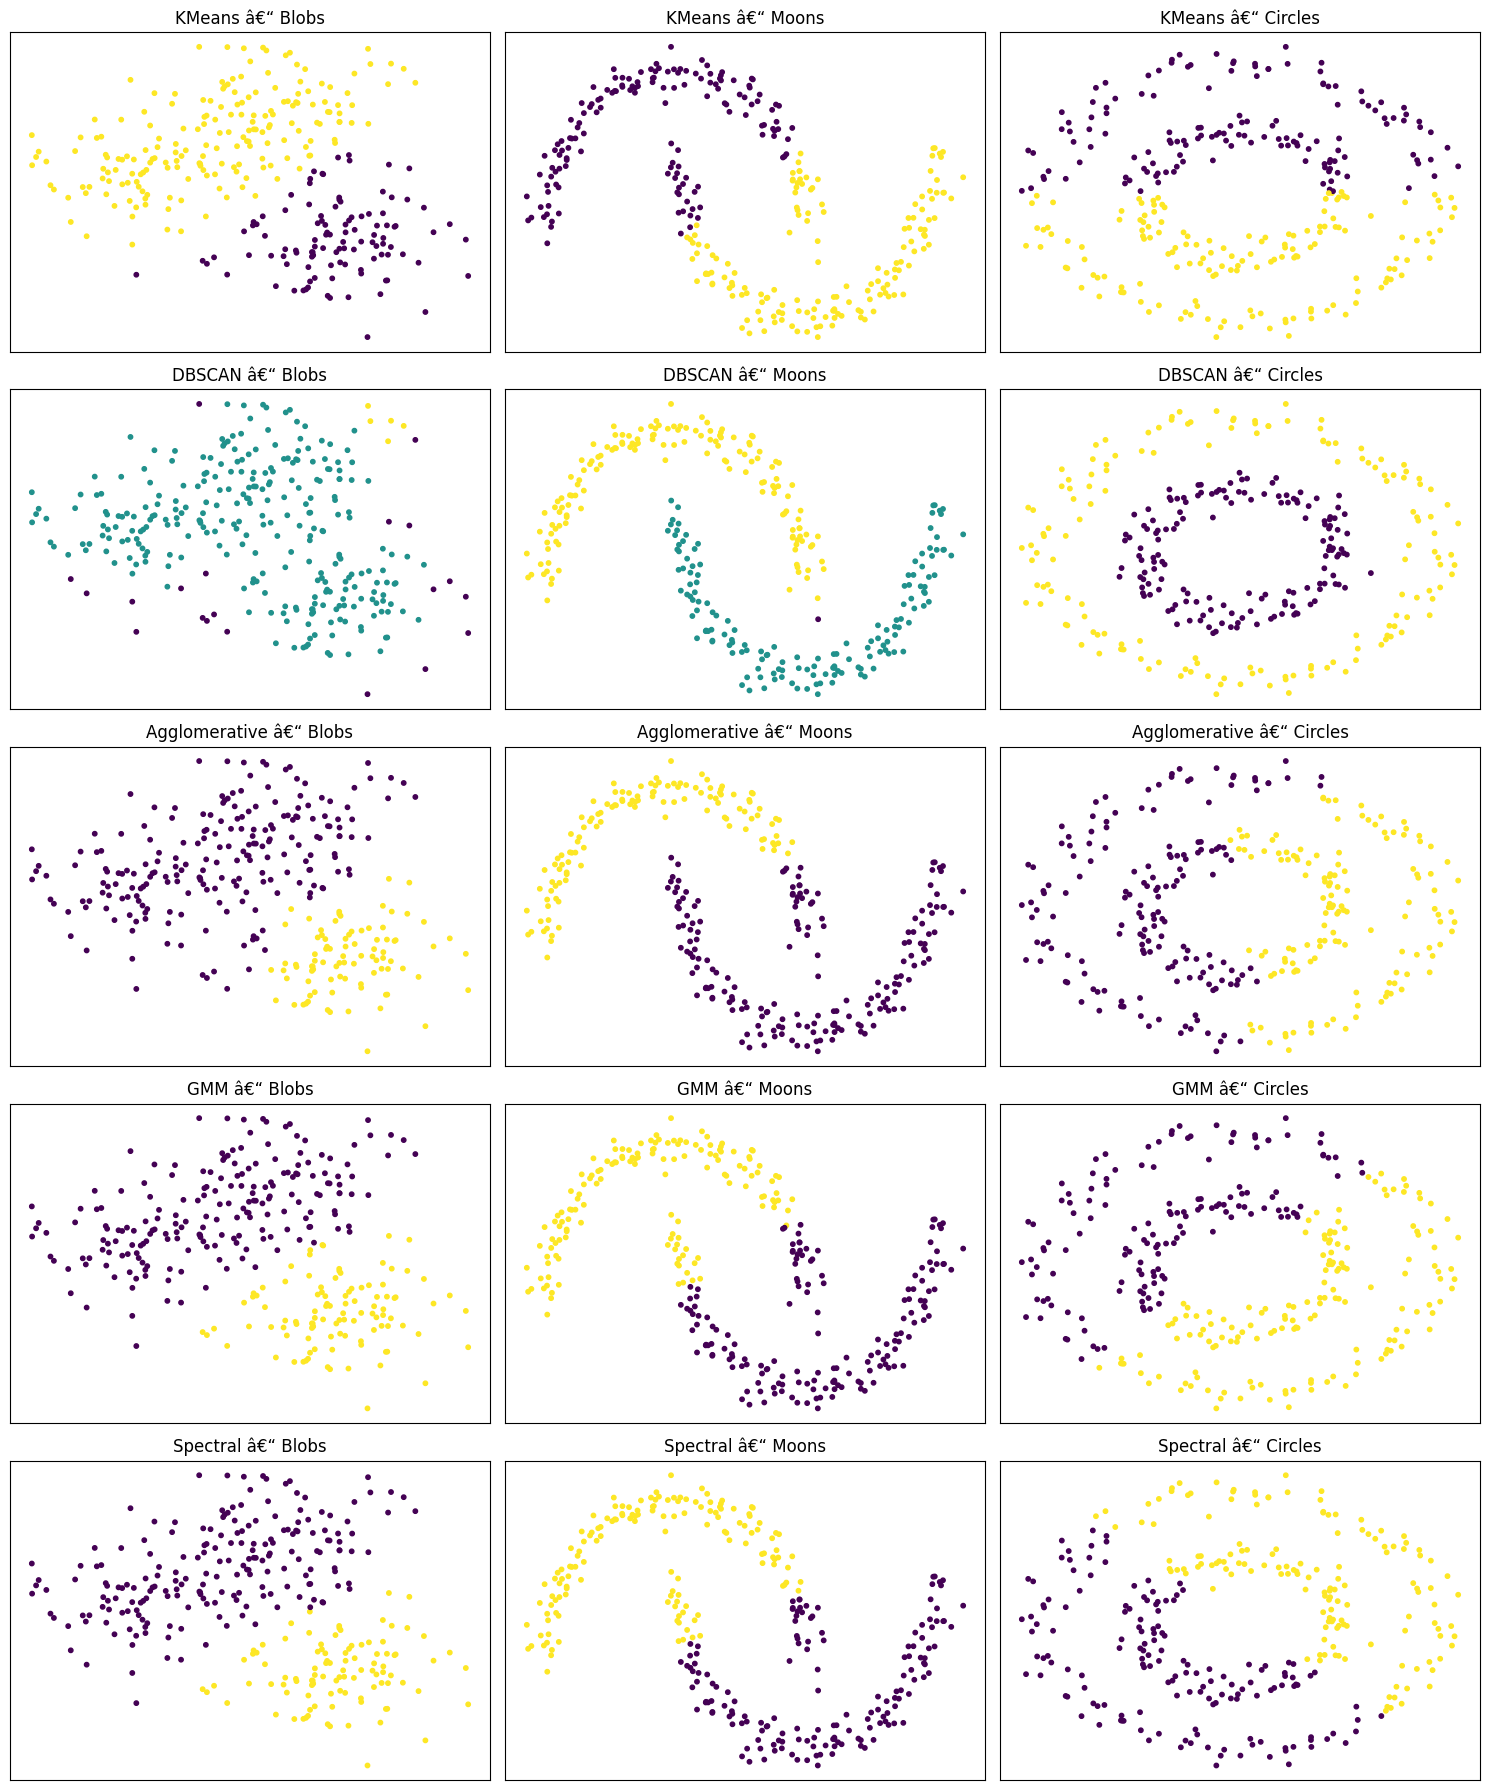

In [40]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# --- 1. Datasets ---
blobs_X, _ = datasets.make_blobs(n_samples=300, centers=3, random_state=0)
moons_X, _ = datasets.make_moons(n_samples=300, noise=0.07, random_state=0)
circles_X, _ = datasets.make_circles(n_samples=300, noise=0.07, factor=0.5, random_state=0)

datasets_list = [
    ("Blobs", blobs_X),
    ("Moons", moons_X),
    ("Circles", circles_X)
]

methods = ["KMeans", "DBSCAN", "Agglomerative", "GMM", "Spectral"]

plt.figure(figsize=(15, 18))

for col_idx, (ds_name, X) in enumerate(datasets_list):
    standardscaler = StandardScaler()
    X_scaled = standardscaler.fit_transform(X)

    # Przygotowanie etykiet metod
    # --- KMeans ---
    kmeans = KMeans(n_clusters=2)
    kmeans_labels = kmeans.fit_predict(X_scaled)

    # --- DBSCAN ---
    dbscan = DBSCAN(eps=0.35, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_scaled)

    # --- Agglomerative ---
    agg = AgglomerativeClustering(n_clusters=2)
    agg_labels = agg.fit_predict(X_scaled)

    # --- GMM ---
    gmm = GaussianMixture(n_components=2, random_state=0)
    gmm_labels = gmm.fit_predict(X_scaled)

    # --- Spectral ---
    spectral = SpectralClustering(n_clusters=2)
    spectral_labels = spectral.fit_predict(X_scaled)

    results = [
        ("KMeans", kmeans_labels),
        ("DBSCAN", dbscan_labels),
        ("Agglomerative", agg_labels),
        ("GMM", gmm_labels),
        ("Spectral", spectral_labels)
    ]

    for row_idx, (method_name, labels) in enumerate(results):
        plt.subplot(len(results), len(datasets_list), row_idx * len(datasets_list) + col_idx + 1)
        plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=10)
        plt.title(f"{method_name} â€“ {ds_name}")
        plt.xticks([])
        plt.yticks([])

plt.tight_layout()
plt.show()


## Najlepsze wino

Celem zadania jest **znalezienie najlepszej kombinacji operacji przetwarzania danych i klasyfikatora** dla zbioru **Wine Quality Red**.

**Uwaga**
Komplet punktÃ³w (2pkt) otrzymasz tylko za osiÄ…gniÄ™cie wyniku powyÅ¼ej 90%.

â­ï¸ W kaÅ¼dej grupie trzy osoby, ktÃ³re otrzymajÄ… najlepszy wynik do koÅ„ca trwania Ä‡wiczeÅ„, otrzymajÄ… punkt bonusowy. Ten sam punkt otrzyma kada osoba, ktÃ³ra pÅ¼ekroczy prÃ³g 96%.

---

#### Opis zadania

1. Wczytaj zbiÃ³r danych **Wine Quality Red** z OpenML (`data_id=41116`).
2. ZamieÅ„ etykiety jakoÅ›ci wina na **klasyfikacjÄ™ binarnÄ…**: dobra (>=6) / sÅ‚aba (<6).
3. Podziel dane na zbiÃ³r treningowy i testowy.
4. Na poczÄ…tek zastosuj **baseline**:

   * bez skalowania,
   * bez redukcji wymiarÃ³w,
   * prosty klasyfikator, np. `RandomForestClassifier(n_estimators=100)`.
     Oblicz dokÅ‚adnoÅ›Ä‡ i classification_report.
5. NastÄ™pnie stwÃ³rz **pipeline**.
6. PorÃ³wnaj wyniki z baseline i wybierz najlepszÄ… kombinacjÄ™ parametrÃ³w, ktÃ³rÄ… uwaÅ¼asz za optymalnÄ….
7. Zapisz wyniki i wnioski: ktÃ³re kombinacje poprawiajÄ… dokÅ‚adnoÅ›Ä‡, a ktÃ³re pogarszajÄ….

In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report

# 1. Wczytanie danych
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
data = pd.read_csv(url, sep=";")
X = data.drop("quality", axis=1)
y = (data["quality"] >= 6).astype(int)  # binarna klasyfikacja: dobra (1) / sÅ‚aba (0)

# 2. PodziaÅ‚ na zbiÃ³r treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Baseline: RandomForest
baseline_clf = RandomForestClassifier(n_estimators=10, random_state=42)
baseline_clf.fit(X_train, y_train)
y_pred = baseline_clf.predict(X_test)

# 4. Ewaluacja
print("=== Najprostszy Baseline ===")
print(f"DokÅ‚adnoÅ›Ä‡: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# 5. Twoje roziwÄ…zanie z Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10, whiten=True, svd_solver='randomized')),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

pipe.fit(X_train, y_train)
y_pred_pipe = pipe.predict(X_test)

print("=== Pipeline: Skalowanie + PCA + RandomForest ===")
print(f"Dokładność: {accuracy_score(y_test, y_pred_pipe):.4f}")
print(classification_report(y_test, y_pred_pipe))


=== Najprostszy Baseline ===
DokÅ‚adnoÅ›Ä‡: 0.7771
              precision    recall  f1-score   support

           0       0.76      0.77      0.76       223
           1       0.80      0.79      0.79       257

    accuracy                           0.78       480
   macro avg       0.78      0.78      0.78       480
weighted avg       0.78      0.78      0.78       480

=== Pipeline: Skalowanie + PCA + RandomForest ===
Dokładność: 0.8000
              precision    recall  f1-score   support

           0       0.79      0.78      0.78       223
           1       0.81      0.82      0.81       257

    accuracy                           0.80       480
   macro avg       0.80      0.80      0.80       480
weighted avg       0.80      0.80      0.80       480



# â­ï¸ Oczyszczanie obrazÃ³w cyfr

Celem zadania jest **przetestowanie metod denoisingu obrazÃ³w cyfr** przy uÅ¼yciu klasycznego PCA i Kernel PCA. BÄ™dziesz pracowaÄ‡ na zbiorze **USPS digits**, ktÃ³ry zawiera obrazy 16Ã—16 pikseli przedstawiajÄ…ce cyfry 0â€“9.

## **Kilka wyjaÅ›nieÅ„:**

* **PCA (Principal Component Analysis)**: klasyczna metoda redukcji wymiarÃ³w, ktÃ³ra znajduje gÅ‚Ã³wne kierunki wariancji w danych. W denoisingu obrazy sÄ… przybliÅ¼ane przez wybrane komponenty, co pozwala odfiltrowaÄ‡ szum.

* **Kernel PCA**: rozszerzenie PCA, ktÃ³re dziaÅ‚a w **przestrzeni cech nieliniowych** dziÄ™ki funkcji jÄ…dra (`kernel`). DziÄ™ki temu metoda moÅ¼e uchwyciÄ‡ bardziej zÅ‚oÅ¼one, nieliniowe struktury w danych, co czasem pozwala na lepsze oczyszczenie szumu.

* **`inverse_transform`**: metoda, ktÃ³ra pozwala **odtworzyÄ‡ pierwotne dane** z przestrzeni zredukowanych cech. W PCA i Kernel PCA moÅ¼emy wiÄ™c zamieniÄ‡ reprezentacjÄ™ niskowymiarowÄ… z powrotem na obraz w oryginalnej przestrzeni pikseli.

---

# **Twoje zadania**

1. **Wczytaj dane USPS** i przeskaluj je do zakresu (0, 1).
2. **Podziel dane** na zbiÃ³r treningowy i testowy.
3. **Dodaj szum gaussowski** do obu zbiorÃ³w, tworzÄ…c wersje zaszumione.
4. **WyÅ›wietl przykÅ‚adowe obrazy** oryginalne i zaszumione, aby zobaczyÄ‡ efekt szumu.
5. **Naucz PCA i Kernel PCA** na zaszumionych obrazach treningowych.
6. **Zrekonstruuj obrazy testowe** uÅ¼ywajÄ…c `inverse_transform` i oblicz MSE (Mean Squared Error).
7. **PorÃ³wnaj wizualnie i iloÅ›ciowo** jakoÅ›Ä‡ rekonstrukcji i napisz krÃ³tkie wnioski.

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA, KernelPCA

# -----------------------------
# 1. Wczytanie i przygotowanie danych
# -----------------------------
X, y = fetch_openml(data_id=41082, as_frame=False, return_X_y=True)
X = # UzupeÅ‚nij

# -----------------------------
# 2. PodziaÅ‚ na zbiÃ³r treningowy i testowy
# -----------------------------
X_train, X_test, y_train, y_test = # UzupeÅ‚nij (test size 100)

# -----------------------------
# 3. Dodanie szumu
# -----------------------------
rng = np.random.RandomState(0)
X_train_noisy = X_train + rng.normal(scale=0.25, size=X_train.shape)
X_test_noisy = X_test + rng.normal(scale=0.25, size=X_test.shape)

# -----------------------------
# 4. Funkcja pomocnicza do wizualizacji obrazÃ³w
# -----------------------------
def plot_digits(X, title):
    """WyÅ›wietla 100 obrazÃ³w w siatce 10x10."""
    fig, axs = plt.subplots(nrows=10, ncols=10, figsize=(8, 8))
    for img, ax in zip(X, axs.ravel()):
        ax.imshow(img.reshape((16, 16)), cmap="Greys")
        ax.axis("off")
    fig.suptitle(title, fontsize=16)
    plt.show()

# -----------------------------
# 5. WyÅ›wietlenie przykÅ‚adowych obrazÃ³w
# -----------------------------
plot_digits(X_test, "Uncorrupted test images")
mse_noisy = np.mean((X_test - X_test_noisy) ** 2)
plot_digits(X_test_noisy, f"Noisy test images\nMSE: {mse_noisy:.2f}")

# -----------------------------
# 6. Nauczenie PCA i Kernel PCA
# -----------------------------
pca = # UzupeÅ‚nij
kernel_pca = # UzupeÅ‚nij

pca.fit(X_train_noisy)
kernel_pca.fit(X_train_noisy)

# -----------------------------
# 7. Rekonstrukcja obrazÃ³w testowych
# -----------------------------
X_reconstructed_pca = # UzupeÅ‚nij
X_reconstructed_kernel_pca = # UzupeÅ‚nij

# -----------------------------
# 8. WyÅ›wietlenie wynikÃ³w i MSE
# -----------------------------
plot_digits(X_test, "Uncorrupted test images")
plot_digits(
    X_reconstructed_pca,
    f"PCA reconstruction\nMSE: {np.mean((X_test - X_reconstructed_pca) ** 2):.2f}",
)
plot_digits(
    X_reconstructed_kernel_pca,
    f"Kernel PCA reconstruction\nMSE: {np.mean((X_test - X_reconstructed_kernel_pca) ** 2):.2f}",
)


SyntaxError: invalid syntax (3307863967.py, line 12)